In [16]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = pd.read_csv("C:\\Users\\acer\\OneDrive\\Documents\\python course\\student_data_60.csv")
    

print("Dataset Preview:")
print(data.head())


Dataset Preview:
   study_hours  attendance  previous_marks  assignments  pass
0            1          50              40            2     0
1            2          55              45            2     0
2            2          60              50            3     0
3            3          65              55            3     0
4            3          70              60            4     1


In [17]:
X = data.drop('pass', axis=1)
y = data['pass']

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     60 non-null     int64
 1   attendance      60 non-null     int64
 2   previous_marks  60 non-null     int64
 3   assignments     60 non-null     int64
 4   pass            60 non-null     int64
dtypes: int64(5)
memory usage: 2.5 KB


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = DecisionTreeClassifier(criterion='gini', max_depth=50, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 100.00%


In [23]:
sample = [[5, 80, 70, 5]]
prediction = model.predict(sample)

print("\nSample Input:", sample)
print("Prediction:", "Pass ✅" if prediction[0] == 1 else "Fail ❌")


Sample Input: [[5, 80, 70, 5]]
Prediction: Pass ✅


c:\Users\acer\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


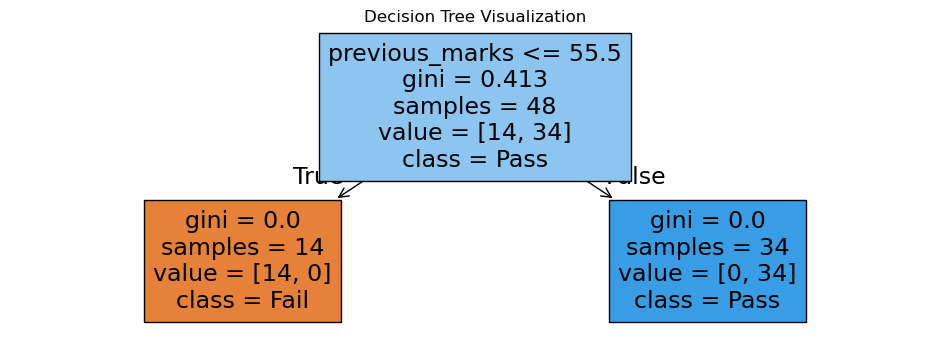

In [24]:
plt.figure(figsize=(12, 4))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.savefig("decision_tree.png")
plt.show()

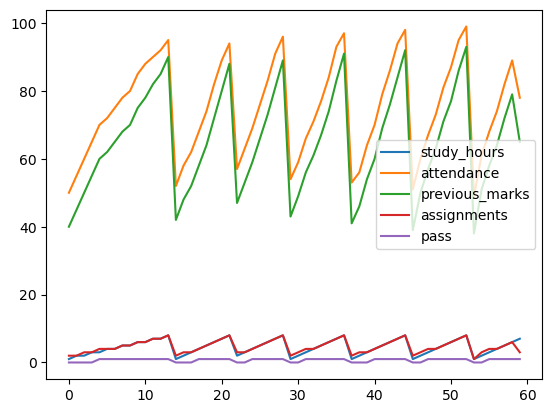

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\\Users\\acer\\OneDrive\\Documents\\python course\\student_data_60.csv")

df.plot()

plt.show()


In [26]:
print("\n--- Predict Student Result ---")
try:
    sh = int(input("Study Hours: "))
    att = int(input("Attendance: "))
    marks = int(input("Previous Marks: "))
    assign = int(input("Assignments: "))

    user = [[sh, att, marks, assign]]
    result = model.predict(user)

    print("\nResult:", "Pass ✅" if result[0] == 1 else "Fail ❌")

except:
    print("Invalid input")


--- Predict Student Result ---
Invalid input


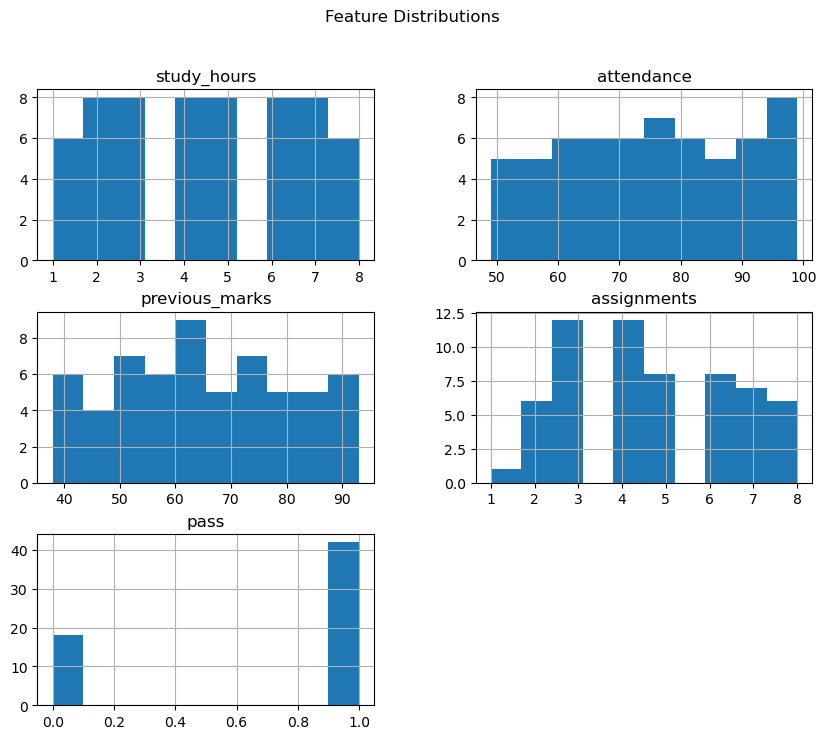

In [27]:
data.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

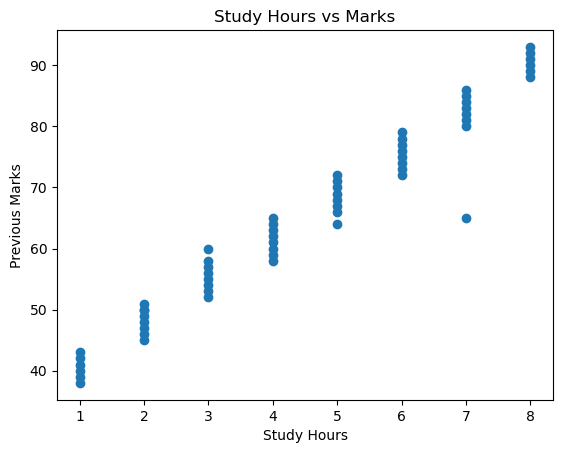

In [28]:
plt.scatter(data['study_hours'], data['previous_marks'])
plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Study Hours vs Marks")
plt.show()

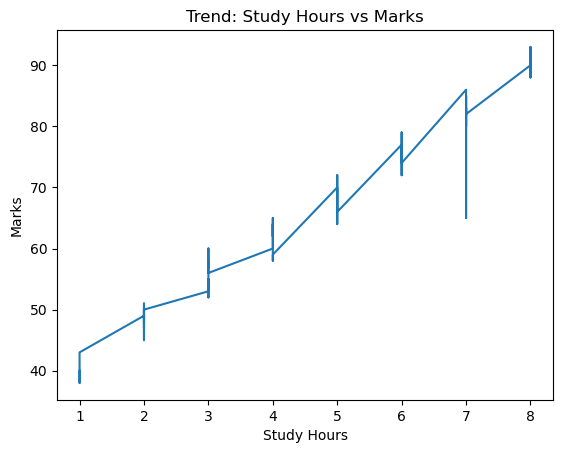

In [29]:
data_sorted = data.sort_values(by='study_hours')

plt.plot(data_sorted['study_hours'], data_sorted['previous_marks'])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Trend: Study Hours vs Marks")
plt.show()

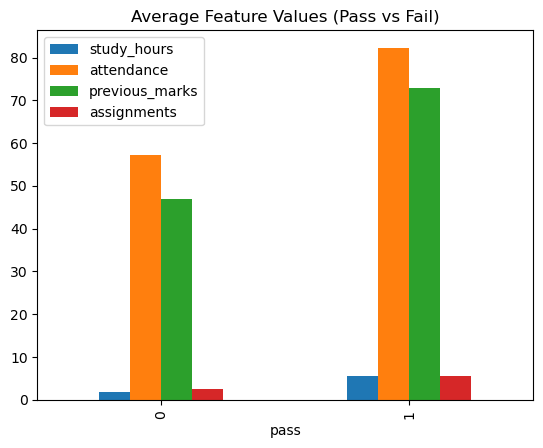

In [30]:
avg_values = data.groupby('pass').mean()

avg_values.plot(kind='bar')
plt.title("Average Feature Values (Pass vs Fail)")
plt.show()

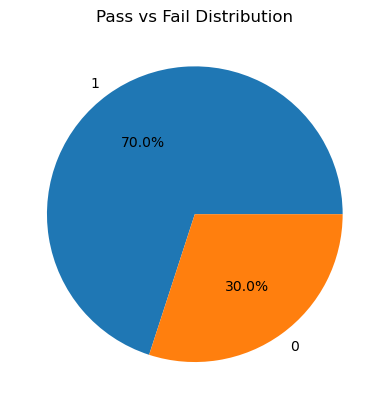

In [31]:
data['pass'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Pass vs Fail Distribution")
plt.ylabel("")
plt.show()

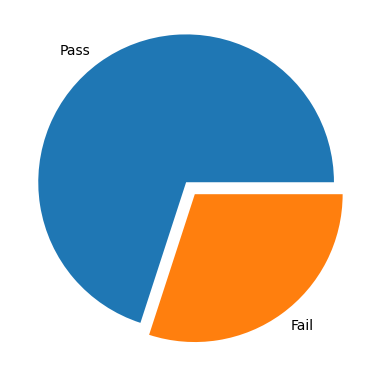

In [32]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array([70, 30])  # Example values for Pass and Fail
mylabels = ["Pass", "Fail"]
myexplode = [0.1, 0]

plt.pie(y, labels = mylabels, explode = myexplode)
plt.show() 

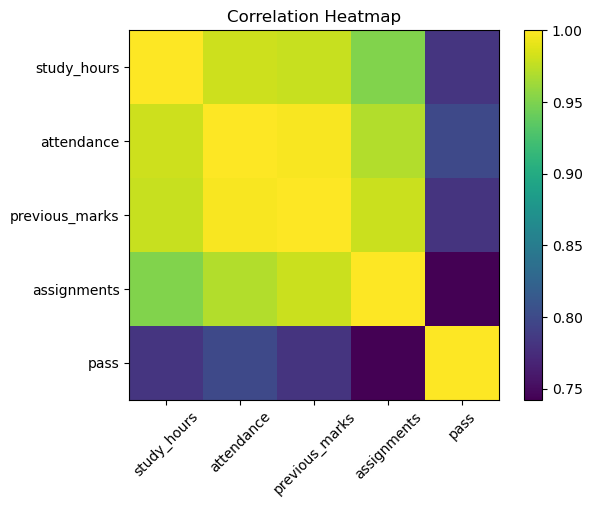

In [33]:
import numpy as np

corr = data.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

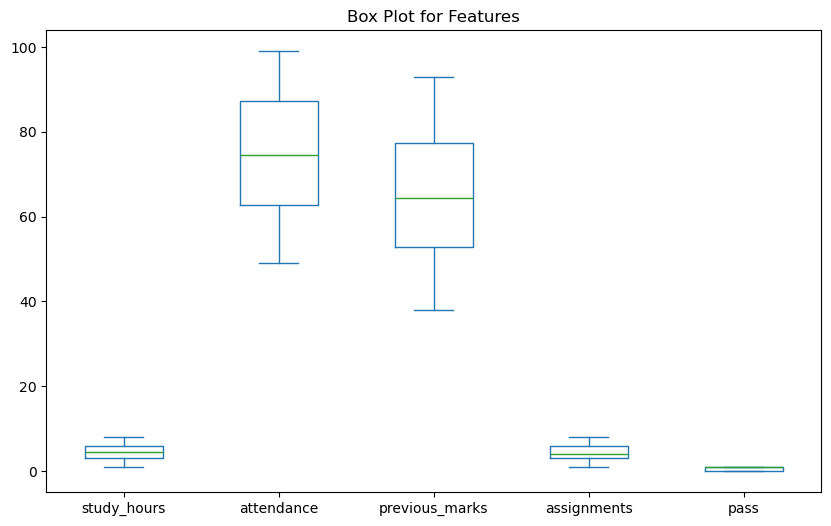

In [34]:
data.plot(kind='box', figsize=(10,6))
plt.title("Box Plot for Features")
plt.show()

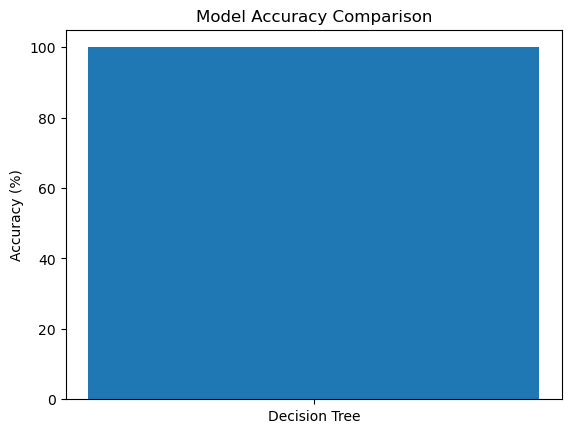

In [35]:
models = ['Decision Tree']
accuracies = [accuracy * 100]

plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.show()

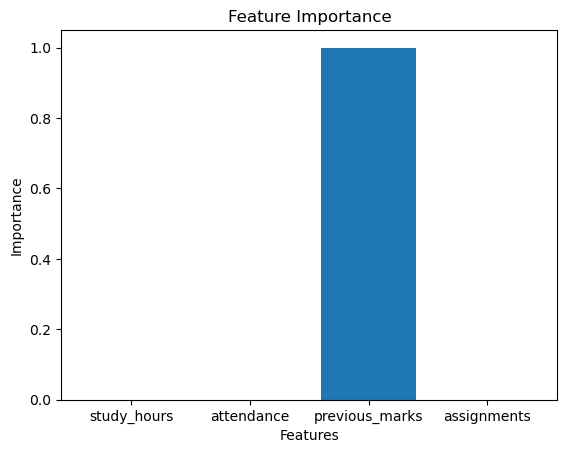

In [36]:
importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

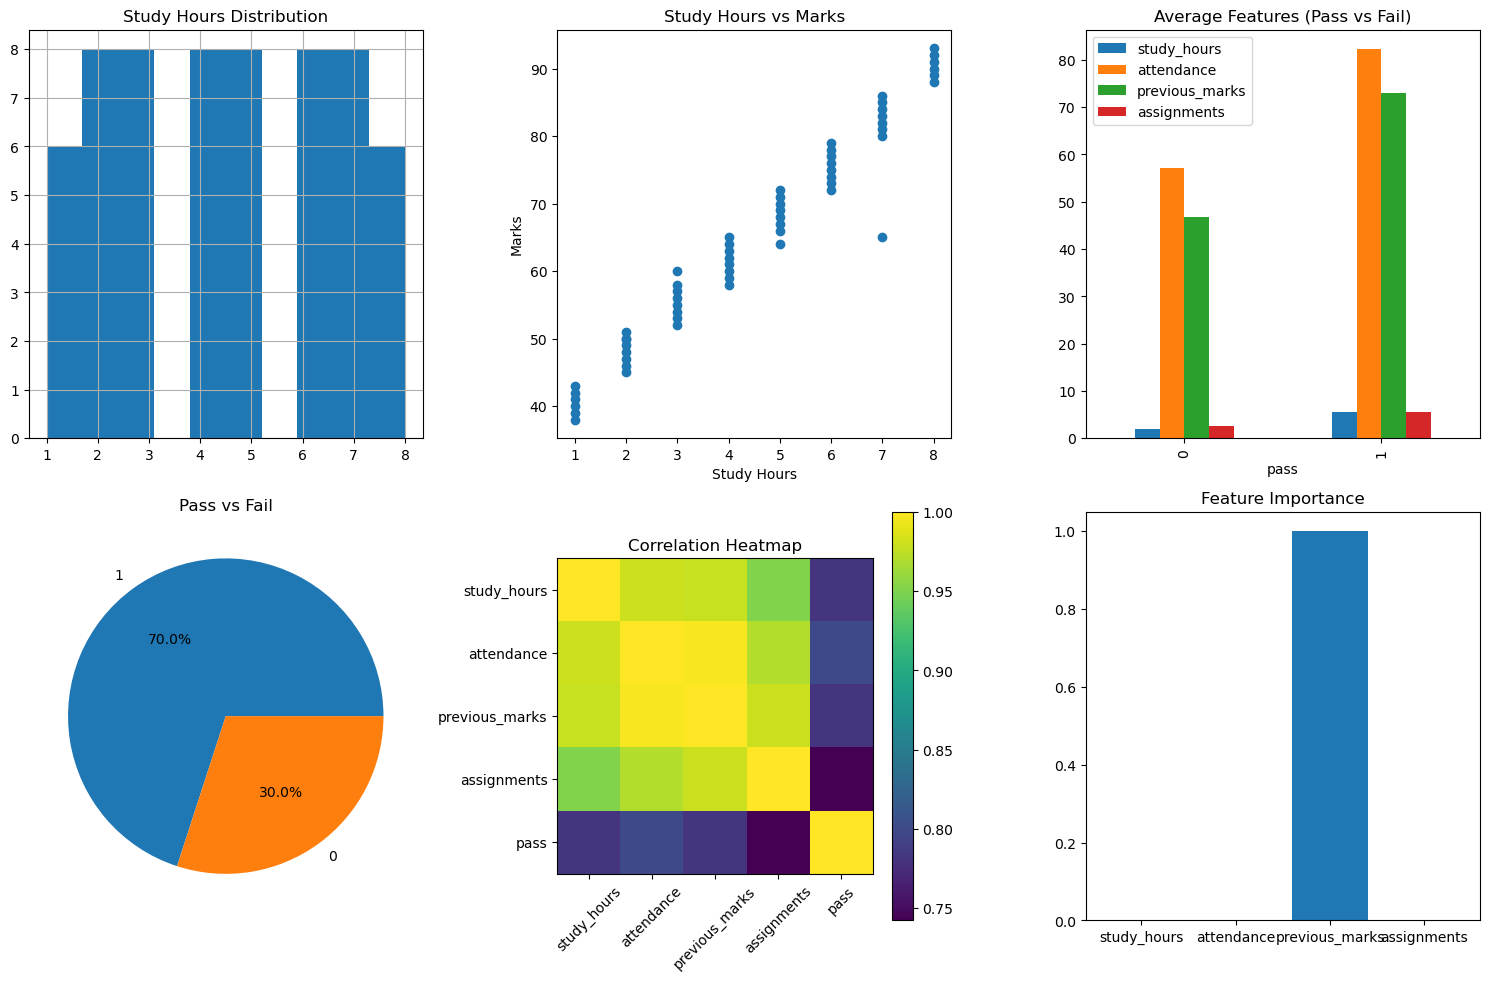

In [37]:
import numpy as np

plt.figure(figsize=(15, 10))

# 1. Histogram
plt.subplot(2, 3, 1)
data['study_hours'].hist()
plt.title("Study Hours Distribution")

# 2. Scatter Plot
plt.subplot(2, 3, 2)
plt.scatter(data['study_hours'], data['previous_marks'])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")

# 3. Bar Chart (Pass vs Fail Avg)
plt.subplot(2, 3, 3)
data.groupby('pass').mean().plot(kind='bar', ax=plt.gca())
plt.title("Average Features (Pass vs Fail)")

# 4. Pie Chart
plt.subplot(2, 3, 4)
data['pass'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Pass vs Fail")
plt.ylabel("")

# 5. Heatmap
plt.subplot(2, 3, 5)
corr = data.corr()
plt.imshow(corr)
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()

# 6. Feature Importance
plt.subplot(2, 3, 6)
importance = model.feature_importances_
plt.bar(X.columns, importance)
plt.title("Feature Importance")

plt.tight_layout()
plt.show()